#  Importing the libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout, TimeDistributed , Bidirectional
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
from scipy.signal import welch, spectrogram
import random
import seaborn as sns
from keras.layers import BatchNormalization



# Load the Dataset

In [2]:
# Load the data
data = pd.read_csv('D:\\EpilepticData.csv', delimiter=',')

# Read and Show Dataset

In [3]:
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
data['y'].value_counts()


y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

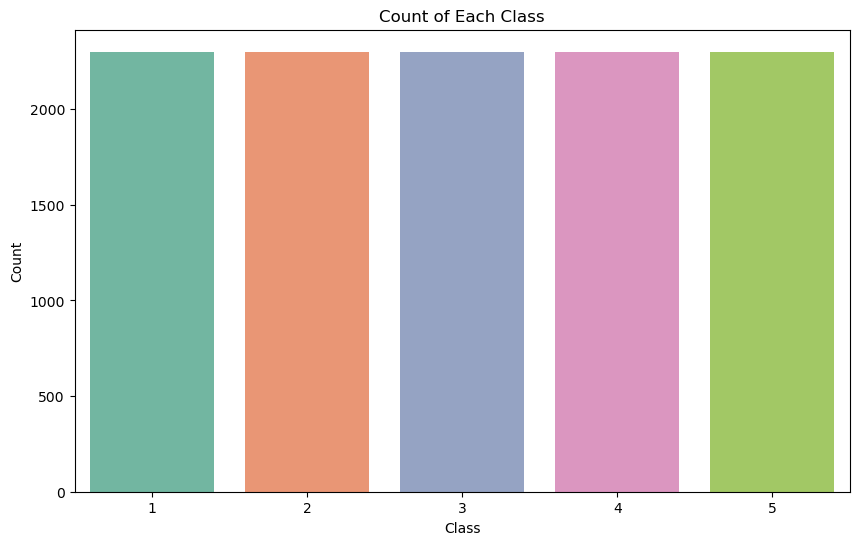

In [5]:
# Create a count plot for the 'y' column
plt.figure(figsize=(10, 6))
sns.countplot(x='y', data=data, palette='Set2')  # Set2 is a color palette
plt.title('Count of Each Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

1 | 2 | 3 | 4 | 5
--- | --- | --- | --- | ---
*Non-Epileptic* | *Non-Epileptic* | `Epileptic` | `Epileptic` | `Epileptic`
Eyes Opened | Eyes Closed | Interictal | Interictal | Ictal

In [6]:
data = data.drop(columns=['Unnamed'])


In [7]:
data.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


# Data Analysis

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 179 entries, X1 to y
dtypes: int64(179)
memory usage: 15.7 MB


In [9]:
#check the shape and info of the data
data.shape


(11500, 179)

In [10]:
# General Statistics of the Data
data.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


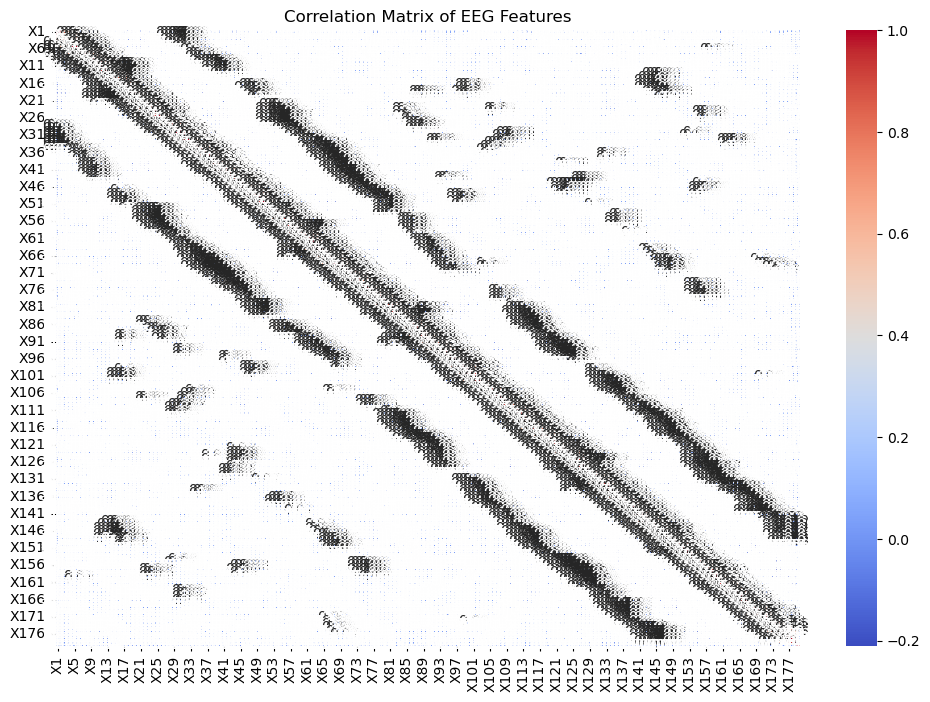

In [12]:
# Correlation Matrix (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of EEG Features')
plt.show()


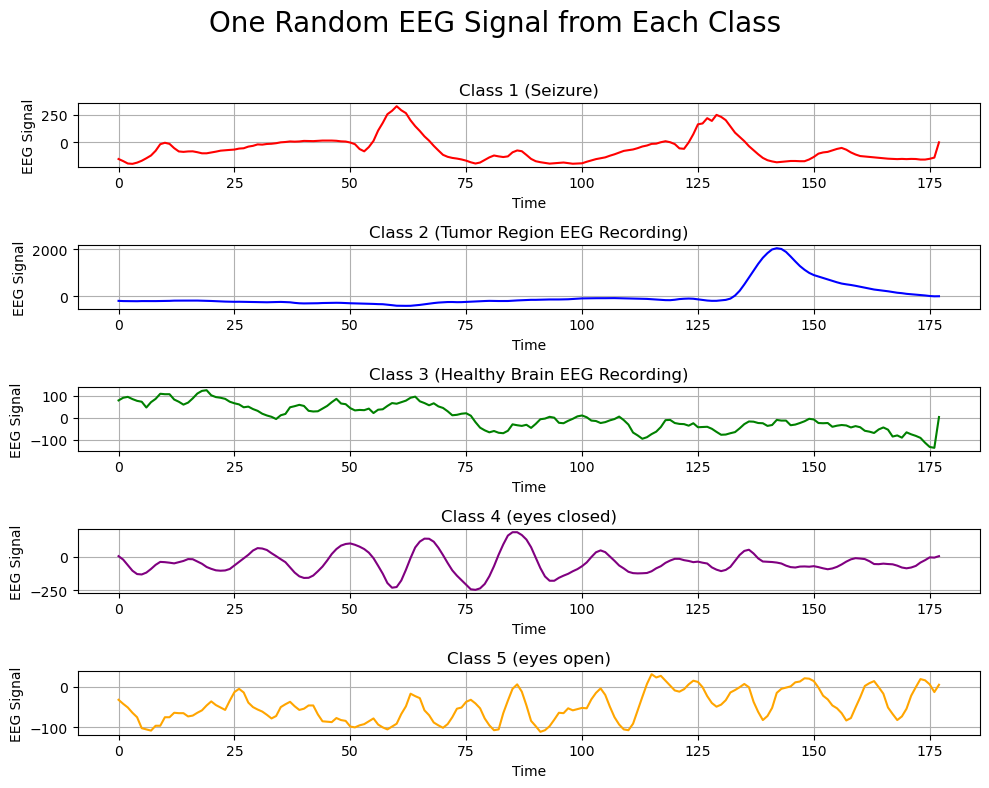

In [11]:
# Constants for class labels
LABEL_C1 = 1
LABEL_C2 = 2
LABEL_C3 = 3
LABEL_C4 = 4
LABEL_C5 = 5

# Prepare empty arrays to collect one sample for each class (Assuming 178 data points per signal)
samples_c1 = np.empty((0, 178), int)
samples_c2 = np.empty((0, 178), int)
samples_c3 = np.empty((0, 178), int)
samples_c4 = np.empty((0, 178), int)
samples_c5 = np.empty((0, 178), int)

# Collect one sample for each class
while len(samples_c1) < 1:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C1:
        samples_c1 = np.vstack((samples_c1, data.iloc[curID, 1:179].values))  # Adjust EEG data

while len(samples_c2) < 1:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C2:
        samples_c2 = np.vstack((samples_c2, data.iloc[curID, 1:179].values))

while len(samples_c3) < 1:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C3:
        samples_c3 = np.vstack((samples_c3, data.iloc[curID, 1:179].values))

while len(samples_c4) < 1:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C4:
        samples_c4 = np.vstack((samples_c4, data.iloc[curID, 1:179].values))

while len(samples_c5) < 1:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C5:
        samples_c5 = np.vstack((samples_c5, data.iloc[curID, 1:179].values))

# Plot the samples
fig = plt.figure(figsize=(10, 8))

# Plot for Class 1
plt.subplot(511)
plt.plot(samples_c1[0], color='red')
plt.title("Class 1 (Seizure)")
plt.xlabel('Time')
plt.ylabel('EEG Signal')
plt.grid()

# Plot for Class 2
plt.subplot(512)
plt.plot(samples_c2[0], color='blue')
plt.title("Class 2 (Tumor Region EEG Recording)")
plt.xlabel('Time')
plt.ylabel('EEG Signal')
plt.grid()

# Plot for Class 3
plt.subplot(513)
plt.plot(samples_c3[0], color='green')
plt.title("Class 3 (Healthy Brain EEG Recording)")
plt.xlabel('Time')
plt.ylabel('EEG Signal')
plt.grid()

# Plot for Class 4
plt.subplot(514)
plt.plot(samples_c4[0], color='purple')
plt.title("Class 4 (eyes closed)")
plt.xlabel('Time')
plt.ylabel('EEG Signal')
plt.grid()

# Plot for Class 5
plt.subplot(515)
plt.plot(samples_c5[0], color='orange')
plt.title("Class 5 (eyes open)")
plt.xlabel('Time')
plt.ylabel('EEG Signal')
plt.grid()

# Main title
fig.suptitle("One Random EEG Signal from Each Class", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title

plt.show()

In [11]:

# Count the occurrences of each class (0 for no seizure, 1 for seizure)
class_counts = data['y'].value_counts()

In [12]:
plt.rcParams['figure.figsize'] = (8, 7)


In [13]:
# Initialize a figure
fig = plt.figure()

<Figure size 800x700 with 0 Axes>

In [15]:

# Define labels for seizure and no seizure
LABEL_C1 = 1  # Class 1 (Seizure)
LABEL_C2 = 0  # Class 0 (No Seizure)

In [16]:

# Collect samples for each class
samples_c1 = np.empty((0, 178), int)  # Adjusted for 178 data points
while len(samples_c1) < 4:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C1:
        samples_c1 = np.vstack((samples_c1, data.iloc[curID, 1:179].values))  # Take EEG data

samples_c2 = np.empty((0, 178), int)  # Adjusted for 178 data points
while len(samples_c2) < 4:
    curID = random.randint(0, len(data) - 1)
    if data.iloc[curID]['y'] == LABEL_C2:
        samples_c2 = np.vstack((samples_c2, data.iloc[curID, 1:179].values))  # Take EEG data

# Plot the samples
for i in range(4):
    plt.subplot(421 + i * 2)  # Class 1 plots
    plt.plot(samples_c1[i], color='red')
    plt.title("Seizure")
    plt.xlabel('Time (data points)')
    plt.ylabel('EEG Signal Value')
    plt.grid()

    plt.subplot(421 + i * 2 + 1)  # Class 0 plots
    plt.plot(samples_c2[i], color='blue')
    plt.title("NO Seizure")
    plt.xlabel('Time (data points)')
    plt.ylabel('EEG Signal Value')
    plt.grid()

# Main title
fig.suptitle("EEG Signal Comparison: Seizure vs No Seizure", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title

plt.show()

KeyboardInterrupt: 

# Data Preprocessing

In [14]:
# Split data into features (X) and labels (y)
X = data.drop(columns=['y'])  # All columns except 'y'
y = data['y']  # 'y' column (binary labels)

In [15]:
# Exclude the 'Unnamed' column from fillna by applying only to numeric columns
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())


In [16]:
# Check for and handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.mean(), inplace=True)

In [17]:
data.isnull().sum()


X1      0
X2      0
X3      0
X4      0
X5      0
       ..
X175    0
X176    0
X177    0
X178    0
y       0
Length: 179, dtype: int64

In [18]:
# Convert the 'y' column to binary (1 for class 1, 0 for classes 2, 3, 4, 5)
data['y'] = data['y'].apply(lambda x: 1 if x == 1 else 0)

In [19]:
# Count the occurrences of each class (0 for no seizure, 1 for seizure)
class_counts = data['y'].value_counts()

In [20]:
class_counts

y
0    9200
1    2300
Name: count, dtype: int64

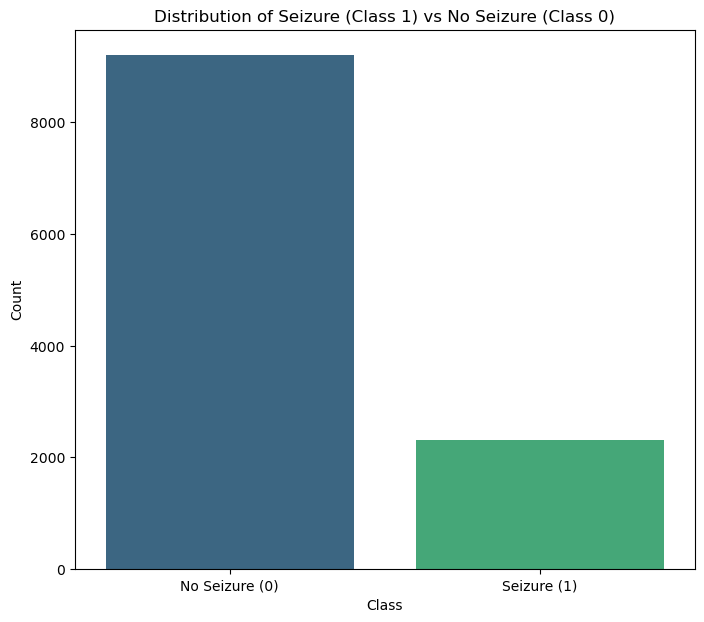

In [21]:
# Plot using seaborn
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Seizure (Class 1) vs No Seizure (Class 0)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Seizure (0)', 'Seizure (1)'])
plt.show()

In [22]:
# Separate features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [23]:
# Binarize the labels
y_binary = np.where(y == 1, 1, 0)


In [24]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)


#  Feature Extraction

In [26]:
from scipy.stats import kurtosis, skew

def extract_time_domain_features(signal):
    mean_val = np.mean(signal)
    var_val = np.var(signal)
    skew_val = skew(signal)
    kurtosis_val = kurtosis(signal)
    zcr = ((signal[:-1] * signal[1:]) < 0).sum()  # Zero Crossing Rate
    return [mean_val, var_val, skew_val, kurtosis_val, zcr]


In [27]:
from scipy.signal import welch

def extract_frequency_domain_features(signal, fs=256):
    # Power Spectral Density (using Welch's method)
    freqs, psd = welch(signal, fs)
    
    # Total power in the EEG signal
    total_power = np.sum(psd)
    
    # Calculate power in specific bands (delta, theta, alpha, beta, gamma)
    delta_power = np.sum(psd[(freqs >= 0.5) & (freqs < 4)])  # Delta (0.5–4 Hz)
    theta_power = np.sum(psd[(freqs >= 4) & (freqs < 8)])   # Theta (4–8 Hz)
    alpha_power = np.sum(psd[(freqs >= 8) & (freqs < 12)])  # Alpha (8–12 Hz)
    beta_power = np.sum(psd[(freqs >= 12) & (freqs < 30)])  # Beta (12–30 Hz)
    gamma_power = np.sum(psd[(freqs >= 30)])                # Gamma (30+ Hz)

    return [total_power, delta_power, theta_power, alpha_power, beta_power, gamma_power]

In [28]:
from scipy.signal import spectrogram

def extract_spectrogram_features(signal, fs=256, nperseg=64):
    freqs, times, Sxx = spectrogram(signal, fs=fs, nperseg=nperseg)
    # Extract statistics from the spectrogram
    mean_spec = np.mean(Sxx)
    var_spec = np.var(Sxx)
    return [mean_spec, var_spec]

In [29]:
from scipy.stats import entropy

def signal_entropy(signal):
    """Calculate signal entropy."""
    psd = np.abs(np.fft.fft(signal))**2  # Power spectral density
    psd_norm = psd / np.sum(psd)  # Normalize
    return entropy(psd_norm)

In [30]:
def extract_additional_features(signal, fs=256):
    entropy_val = signal_entropy(signal)
    return [entropy_val]


In [31]:
def extract_features_from_eeg(signal, fs=256):
    # Time-Domain Features
    time_domain_features = extract_time_domain_features(signal)
    
    # Frequency-Domain Features
    freq_domain_features = extract_frequency_domain_features(signal, fs)
    
    # Spectrogram Features
    spectrogram_features = extract_spectrogram_features(signal, fs)
    
     # Entropy Features
    entropy_features = extract_additional_features(signal, fs)
    
    # Combine all features
    features = time_domain_features + freq_domain_features + spectrogram_features + entropy_features
    return features

# Append entropy to feature names
#feature_names += ['Signal Entropy']

In [32]:
# Assuming X_scaled contains the EEG signals
all_features = []

for signal in X_scaled:
    features = extract_features_from_eeg(signal)
    all_features.append(features)

# Convert to a Pandas DataFrame
feature_names = [
    'Mean', 'Variance', 'Skewness', 'Kurtosis', 'Zero Crossing Rate',
    'Total Power', 'Delta Power', 'Theta Power', 'Alpha Power', 'Beta Power', 'Gamma Power',
    'Spectrogram Mean', 'Spectrogram Variance' , 'Signal Entropy'
]
df_features = pd.DataFrame(all_features, columns=feature_names)

# Display the extracted features
df_features.head(15)

C:\Users\IBM\anaconda3\Lib\site-packages\scipy\signal\_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 178, using nperseg = 178
  warnings.warn('nperseg = {0:d} is greater than input length '


,Mean,Variance,Skewness,Kurtosis,Zero Crossing Rate,Total Power,Delta Power,Theta Power,Alpha Power,Beta Power,Gamma Power,Spectrogram Mean,Spectrogram Variance,Signal Entropy
0,-0.054405,0.337043,-0.186356,0.079175,23,0.296700,0.052515,0.023688,0.002397,0.204256,0.010636,0.002155,5.878895e-05,3.101651
1,0.201706,8.409135,-1.527745,1.408929,8,6.948055,0.987969,3.380763,1.253358,1.155213,0.169505,0.062857,3.867756e-02,3.220481
2,-0.221173,0.071833,0.469674,-0.296220,16,0.038632,0.008623,0.003819,0.006474,0.017346,0.001898,0.000551,2.243803e-06,2.781228
3,-0.372149,0.009241,0.357788,0.214899,0,0.006564,0.001610,0.000773,0.000357,0.003059,0.000543,0.000053,1.300836e-08,0.461393
4,0.005895,0.056105,-0.461339,-0.246283,29,0.027295,0.007804,0.002077,0.003615,0.006839,0.005546,0.000291,4.939296e-07,3.641281
5,0.136611,0.086448,-0.118155,-0.582027,15,0.050235,0.018582,0.003184,0.000380,0.025199,0.001971,0.000409,1.526042e-06,2.877389
6,0.133046,0.154302,-0.069324,-0.687639,21,0.070680,0.003677,0.000973,0.004351,0.057750,0.002916,0.001133,1.239782e-05,3.229469
7,-0.149273,0.050057,-0.682167,-0.324191,9,0.035119,0.017137,0.012047,0.003881,0.001596,0.000168,0.000342,3.833602e-06,2.080369
8,-0.150494,0.846144,-0.097916,-0.087044,12,0.460985,0.011992,0.246219,0.145350,0.046030,0.007833,0.005844,3.475320e-04,3.213648
9,0.071776,0.035722,-0.341199,0.330147,26,0.023992,0.001055,0.001923,0.004060,0.012373,0.004457,0.000271,4.057308e-07,3.502227


In [32]:
# Extract all features and divide them into separate DataFrames
def extract_features_from_eeg(signal, fs=256):
    # Time-Domain Features
    time_domain_features = extract_time_domain_features(signal)
    
    # Frequency-Domain Features
    freq_domain_features = extract_frequency_domain_features(signal, fs)
    
    # Spectrogram Features
    spectrogram_features = extract_spectrogram_features(signal, fs)
    
    return time_domain_features, freq_domain_features, spectrogram_features

# Assuming X_scaled contains the EEG signals
time_domain_features_list = []
frequency_domain_features_list = []
spectrogram_features_list = []

# Loop through each signal in the dataset
for signal in X_scaled:
    time_domain_features, freq_domain_features, spectrogram_features = extract_features_from_eeg(signal)
    time_domain_features_list.append(time_domain_features)
    frequency_domain_features_list.append(freq_domain_features)
    spectrogram_features_list.append(spectrogram_features)

# Time-Domain Features DataFrame
time_domain_feature_names = ['Mean', 'Variance', 'Skewness', 'Kurtosis', 'Zero Crossing Rate']
df_time_domain = pd.DataFrame(time_domain_features_list, columns=time_domain_feature_names)

# Frequency-Domain Features DataFrame
frequency_domain_feature_names = ['Total Power', 'Delta Power', 'Theta Power', 'Alpha Power', 'Beta Power', 'Gamma Power']
df_frequency_domain = pd.DataFrame(frequency_domain_features_list, columns=frequency_domain_feature_names)

# Spectrogram Features DataFrame
spectrogram_feature_names = ['Spectrogram Mean', 'Spectrogram Variance']
df_spectrogram = pd.DataFrame(spectrogram_features_list, columns=spectrogram_feature_names)

C:\Users\IBM\anaconda3\Lib\site-packages\scipy\signal\_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 178, using nperseg = 178
  warnings.warn('nperseg = {0:d} is greater than input length '


In [39]:
df_time_domain.head(11)

,Mean,Variance,Skewness,Kurtosis,Zero Crossing Rate
0,-0.054405,0.337043,-0.186356,0.079175,23
1,0.201706,8.409135,-1.527745,1.408929,8
2,-0.221173,0.071833,0.469674,-0.296220,16
3,-0.372149,0.009241,0.357788,0.214899,0
4,0.005895,0.056105,-0.461339,-0.246283,29
5,0.136611,0.086448,-0.118155,-0.582027,15
6,0.133046,0.154302,-0.069324,-0.687639,21
7,-0.149273,0.050057,-0.682167,-0.324191,9
8,-0.150494,0.846144,-0.097916,-0.087044,12
9,0.071776,0.035722,-0.341199,0.330147,26


In [40]:
df_frequency_domain.head(11)

,Total Power,Delta Power,Theta Power,Alpha Power,Beta Power,Gamma Power
0,0.296700,0.052515,0.023688,0.002397,0.204256,0.010636
1,6.948055,0.987969,3.380763,1.253358,1.155213,0.169505
2,0.038632,0.008623,0.003819,0.006474,0.017346,0.001898
3,0.006564,0.001610,0.000773,0.000357,0.003059,0.000543
4,0.027295,0.007804,0.002077,0.003615,0.006839,0.005546
5,0.050235,0.018582,0.003184,0.000380,0.025199,0.001971
6,0.070680,0.003677,0.000973,0.004351,0.057750,0.002916
7,0.035119,0.017137,0.012047,0.003881,0.001596,0.000168
8,0.460985,0.011992,0.246219,0.145350,0.046030,0.007833
9,0.023992,0.001055,0.001923,0.004060,0.012373,0.004457


In [41]:
df_spectrogram.head(11)

,Spectrogram Mean,Spectrogram Variance
0,0.002155,5.878895e-05
1,0.062857,3.867756e-02
2,0.000551,2.243803e-06
3,0.000053,1.300836e-08
4,0.000291,4.939296e-07
5,0.000409,1.526042e-06
6,0.001133,1.239782e-05
7,0.000342,3.833602e-06
8,0.005844,3.475320e-04
9,0.000271,4.057308e-07


In [95]:
# Scale the extracted features
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(df_features)

In [96]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_features_scaled, y_binary, test_size=0.2, random_state=42)

In [97]:
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("y_train : ",y_train.shape)
print("y_test : ",y_test.shape)


X_train :  (9200, 14)
X_test :  (2300, 14)
y_train :  (9200,)
y_test :  (2300,)


In [90]:
from collections import Counter

print("Training set class distribution:", Counter(y_train))
print("Test set class distribution:", Counter(y_test))


Training set class distribution: Counter({0: 7365, 1: 1835})
Test set class distribution: Counter({0: 1835, 1: 465})


# Model Training

In [68]:
# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [69]:
# Check the shape of the reshaped input data
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (9200, 1, 14)
Shape of X_test: (2300, 1, 14)


In [98]:
# Reshape for CNN


# Reshape X_train and X_test to match the input shape (samples, steps, channels)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # Add channel dimension
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))  # Add channel dimension


In [99]:
# Check the shape of the reshaped input data
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (9200, 14, 1)
Shape of X_test: (2300, 14, 1)


In [160]:
import random
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [101]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, Dense, BatchNormalization

# Model building
model = Sequential()

# First Conv Layer
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))  # Input shape adjusted
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Second Conv Layer
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Flatten the output
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Dropout to reduce overfitting

# Output Layer
model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model

# Model summary
model.summary()


Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_13 (Conv1D)          (None, 12, 64)            256       
                                                                 
 batch_normalization_12 (Ba  (None, 12, 64)            256       
 tchNormalization)                                               
                                                                 
 max_pooling1d_12 (MaxPooli  (None, 6, 64)             0         
 ng1D)                                                           
                                                                 
 conv1d_14 (Conv1D)          (None, 4, 128)            24704     
                                                                 
 batch_normalization_13 (Ba  (None, 4, 128)            512       
 tchNormalization)                                               
                                                     

In [102]:
# Compile the model

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [103]:
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)


In [104]:
# Convert class weights to a dictionary format
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [105]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [106]:
# Fit the model with class weights
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, class_weight=class_weight_dict ,  callbacks=[early_stopping])

Epoch 1/50
115/115 [==============================] - 3s 12ms/step - loss: 0.1654 - accuracy: 0.9542 - val_loss: 0.4446 - val_accuracy: 0.9674
Epoch 2/50
115/115 [==============================] - 1s 9ms/step - loss: 0.0920 - accuracy: 0.9711 - val_loss: 0.2162 - val_accuracy: 0.9696
Epoch 3/50
115/115 [==============================] - 1s 9ms/step - loss: 0.0828 - accuracy: 0.9692 - val_loss: 0.0959 - val_accuracy: 0.9793
Epoch 4/50
115/115 [==============================] - 1s 10ms/step - loss: 0.0765 - accuracy: 0.9753 - val_loss: 0.0877 - val_accuracy: 0.9712
Epoch 5/50
115/115 [==============================] - 1s 10ms/step - loss: 0.0746 - accuracy: 0.9751 - val_loss: 0.0579 - val_accuracy: 0.9810
Epoch 6/50
115/115 [==============================] - 1s 9ms/step - loss: 0.0663 - accuracy: 0.9779 - val_loss: 0.0462 - val_accuracy: 0.9804
Epoch 7/50
115/115 [==============================] - 1s 9ms/step - loss: 0.0644 - accuracy: 0.9758 - val_loss: 0.0578 - val_accuracy: 0.9745
Epo

# Results Visualization

In [62]:
# Evaluate the model on the test set
loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

# Evaluate the model on the training set
loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f'Train Accuracy: {train_accuracy * 100:.2f}%')


Test Accuracy: 98.26%
Train Accuracy: 97.91%


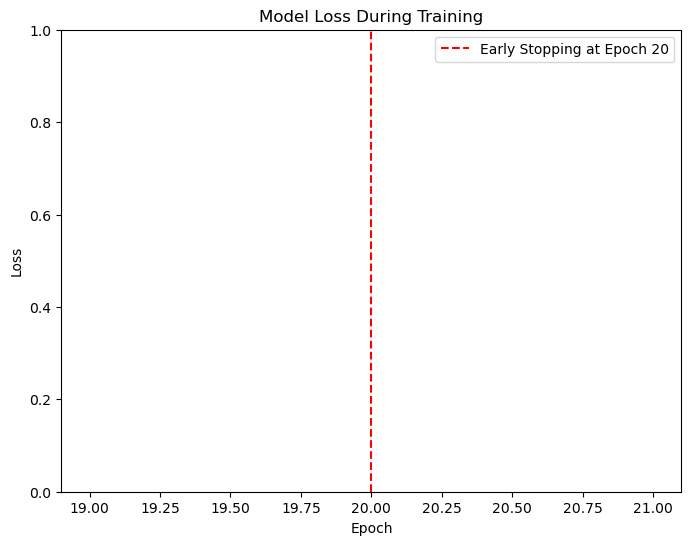

In [81]:
plt.figure(figsize=(8, 6))

stopped_epoch = early_stopping.stopped_epoch + 1  # Adjust for 0-based indexing
if stopped_epoch > 0:
    plt.axvline(stopped_epoch, color='red', linestyle='--', label=f'Early Stopping at Epoch {stopped_epoch}')

# Adding labels and legend
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

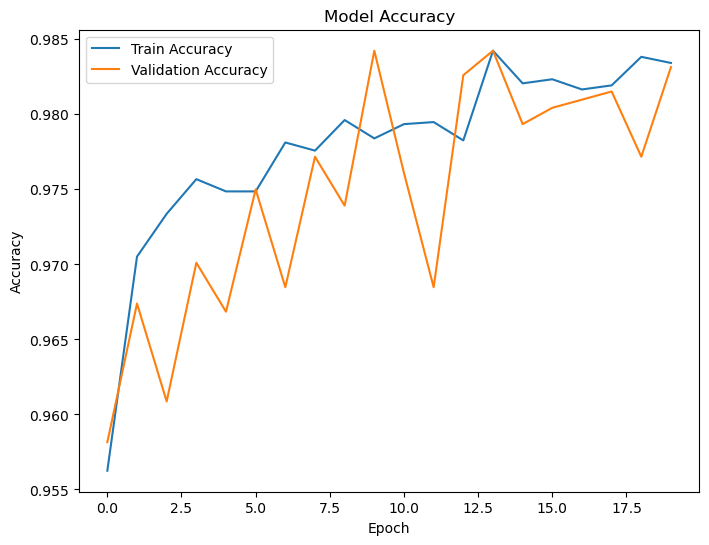

In [82]:
plt.figure(figsize=(8, 6))
# Plotting training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

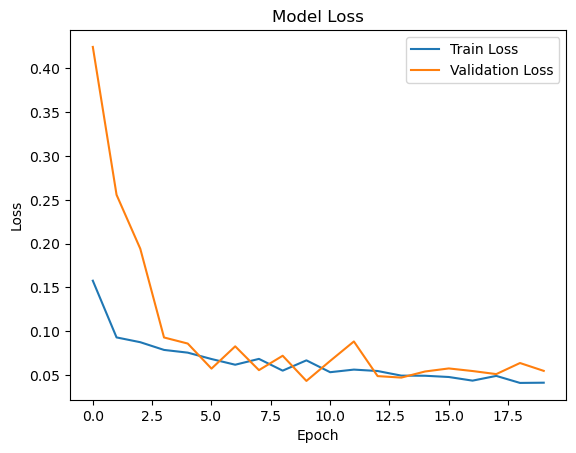

In [83]:
# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [84]:
# Make predictions on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

72/72 [==============================] - 1s 4ms/step


In [85]:
# Load necessary libraries
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Seizure (0)', 'Seizure (1)']))

Classification Report:
                precision    recall  f1-score   support

No Seizure (0)       0.99      0.99      0.99      1835
   Seizure (1)       0.97      0.97      0.97       465

      accuracy                           0.99      2300
     macro avg       0.98      0.98      0.98      2300
  weighted avg       0.99      0.99      0.99      2300



In [86]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


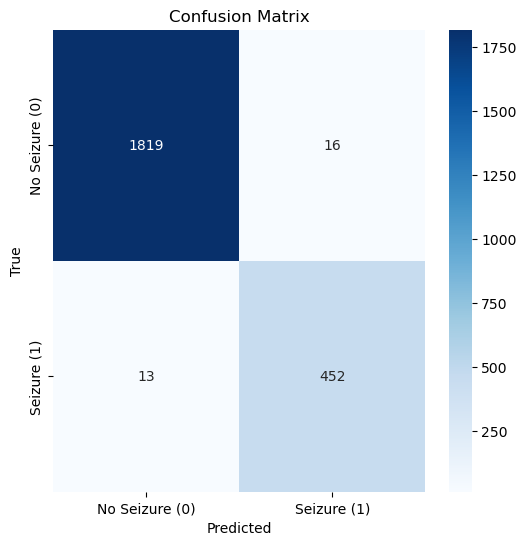

In [87]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Seizure (0)', 'Seizure (1)'], yticklabels=['No Seizure (0)', 'Seizure (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

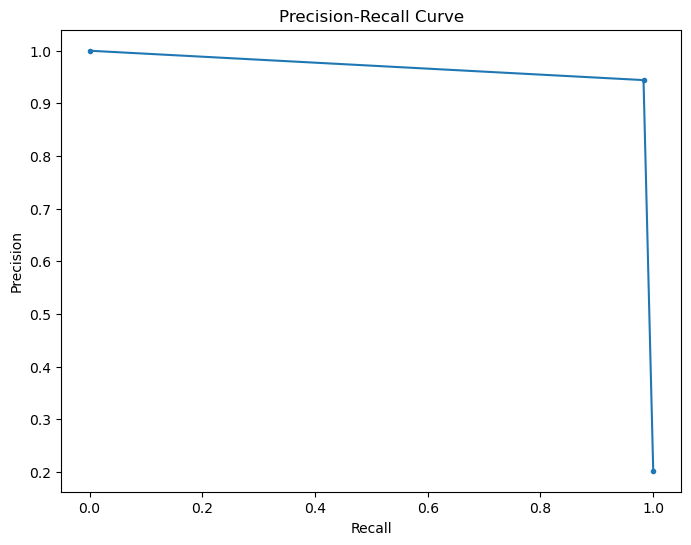

In [98]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8, 6))
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()